# AI-Based Phishing Detection for Smart City

In [ ]:
# Cell 1: Download the SMS Spam Collection dataset
# Using a Kaggle mirror as the original GitHub URL may be unavailable
import urllib.request
import pandas as pd

# Try the Kaggle CSV version
url = "https://raw.githubusercontent.com/mohitgupta-1O1/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"
urllib.request.urlretrieve(url, "spam.csv")
print("Dataset downloaded successfully!")
print(f"File saved as: spam.csv")

Dataset downloaded successfully!
File saved as: spam.csv


In [ ]:
# Cell 2: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [ ]:
# Cell 3: Load the dataset
# The Kaggle CSV has columns: v1 (label), v2 (message)
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Display first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Cell 4: Check dataset size and class distribution
print(f"Dataset contains {df.shape[0]} messages")
print(f"Class distribution:\n{df['label'].value_counts()}")

Dataset contains 5572 messages
Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
# Cell 5: Encode labels: ham -> 0, spam -> 1
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# Verify encoding
print(df[['label', 'label_encoded']].head())
print("\nEncoded class distribution:")
print(df['label_encoded'].value_counts())

  label  label_encoded
0   ham              0
1   ham              0
2  spam              1
3   ham              0
4   ham              0

Encoded class distribution:
label_encoded
0    4825
1     747
Name: count, dtype: int64


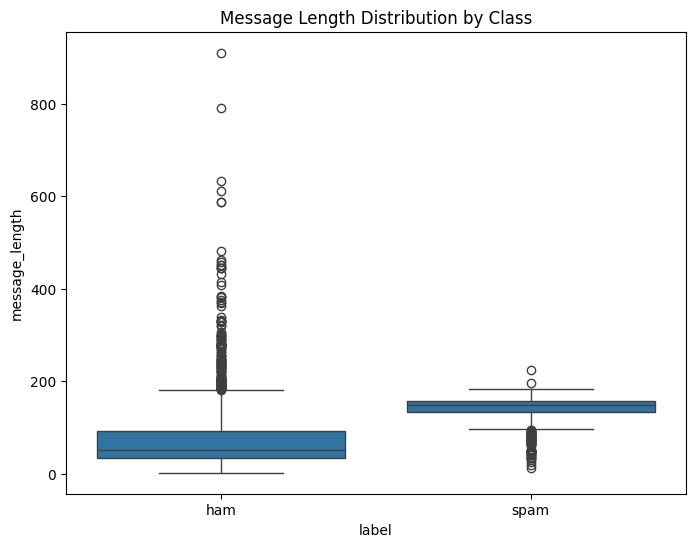

Average length of legitimate (ham) messages: 71.02 characters
Average length of spam messages: 138.87 characters


In [ ]:
# Cell 6: Calculate message lengths and visualize
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='message_length', data=df)
plt.title('Message Length Distribution by Class')
plt.show()

print(f"Average length of legitimate (ham) messages: {df[df['label_encoded']==0]['message_length'].mean():.2f} characters")
print(f"Average length of spam messages: {df[df['label_encoded']==1]['message_length'].mean():.2f} characters")

In [ ]:
# Cell 7: Extract features using Bag of Words
vectorizer = CountVectorizer()

# Convert messages to word count matrix
X = vectorizer.fit_transform(df['message'])

# Extract labels
y = df['label_encoded']

print(f"Feature matrix shape: {X.shape[0]} messages x {X.shape[1]} unique words")

Feature matrix shape: 5572 messages x 8672 unique words


In [ ]:
# Cell 8: Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} messages")
print(f"Testing set size: {X_test.shape[0]} messages")
print(f"Training spam ratio: {y_train.mean():.2%}")
print(f"Testing spam ratio: {y_test.mean():.2%}")

Training set size: 4457 messages
Testing set size: 1115 messages
Training spam ratio: 13.42%
Testing spam ratio: 13.36%


In [ ]:
# Cell 9: Train the Multinomial Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

print("Model training complete")

Model training complete


In [ ]:
# Cell 10: Make predictions on test data
y_pred = model.predict(X_test)

In [ ]:
# Cell 11: Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("========== MODEL PERFORMANCE ==========")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score:  {f1:.4f}")

========== MODEL PERFORMANCE ==========
Accuracy:  0.9812 (98.12%)
Precision: 0.9156 (91.56%)
Recall:    0.9463 (94.63%)
F1 Score:  0.9307


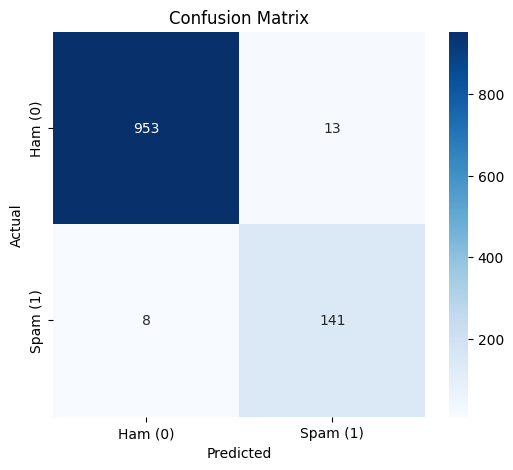

In [ ]:
# Cell 12: Create and visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham (0)', 'Spam (1)'],
            yticklabels=['Ham (0)', 'Spam (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Cell 13: Detailed per-class metrics
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.92      0.95      0.93       149

    accuracy                           0.98      1115
   macro avg       0.95      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [21]:
# Cell 14 – Improved Smart City Email Test (Clean HAM/SPAM Demo)

# Legitimate (HAM) examples – rewritten to avoid triggering spam filters
ham_examples = [
    "Smart parking payment #PK2451 has been processed. Thank you for using city services.",
    "Traffic alert: Congestion expected on Main St between 5 PM and 7 PM.",
    "Your waste collection schedule for next week is now available in the resident portal.",
    "Water meter reading for your property is ready. Log in to the portal to view details."
]

# Phishing (SPAM) examples – retain strong indicators
spam_examples = [
    "URGENT: Your digital ID for smart city services has been suspended. Click http://fake-link.com/verify to restore access now.",
    "Congratulations! You won a 500 smart city voucher. Claim at http://phishy-site.net/claim within 24 hours.",
    "Security Alert: Unusual login detected on your city account. Verify immediately at http://scam-portal.com/secure.",
    "Your smart meter firmware is out of date. Download critical update from this link to avoid service interruption."
]

# Combine all emails
smart_city_emails = ham_examples + spam_examples
expected_labels = ["HAM"] * len(ham_examples) + ["SPAM"] * len(spam_examples)

# Transform using the same vectorizer (do NOT re-fit)
X_custom = vectorizer.transform(smart_city_emails)
predictions = model.predict(X_custom)

# Display results
print("=" * 70)
print("SMART CITY EMAIL CLASSIFICATION RESULTS (IMPROVED DEMO)")
print("=" * 70)

for i, (email, pred, expected) in enumerate(zip(smart_city_emails, predictions, expected_labels)):
    predicted_label = "SPAM" if pred == 1 else "HAM"
    status = "OK" if predicted_label == expected else "MISCLASSIFIED"
    print(f"\n{status} Email {i+1}: {email[:70]}...")
    print(f"   Expected: {expected} | Predicted: {predicted_label}")

SMART CITY EMAIL CLASSIFICATION RESULTS (IMPROVED DEMO)

MISCLASSIFIED Email 1: Smart parking payment #PK2451 has been processed. Thank you for using ...
   Expected: HAM | Predicted: SPAM

MISCLASSIFIED Email 2: Traffic alert: Congestion expected on Main St between 5 PM and 7 PM....
   Expected: HAM | Predicted: SPAM

MISCLASSIFIED Email 3: Your waste collection schedule for next week is now available in the r...
   Expected: HAM | Predicted: SPAM

OK Email 4: Water meter reading for your property is ready. Log in to the portal t...
   Expected: HAM | Predicted: HAM

OK Email 5: URGENT: Your digital ID for smart city services has been suspended. Cl...
   Expected: SPAM | Predicted: SPAM

OK Email 6: Congratulations! You won a 500 smart city voucher. Claim at http://phi...
   Expected: SPAM | Predicted: SPAM

OK Email 7: Security Alert: Unusual login detected on your city account. Verify im...
   Expected: SPAM | Predicted: SPAM

OK Email 8: Your smart meter firmware is out of date. Do

In [ ]:
# Cell 15: Save model and vectorizer
import joblib

# Save model and vectorizer
joblib.dump(model, 'spam_classifier_model.pkl')
joblib.dump(vectorizer, 'count_vectorizer.pkl')

print("Model and vectorizer saved successfully!")
print("Files created: spam_classifier_model.pkl, count_vectorizer.pkl")

Model and vectorizer saved successfully!
Files created: spam_classifier_model.pkl, count_vectorizer.pkl
